<a href="https://colab.research.google.com/github/nulahaa-cpu/AIFFEL_quest_cr/blob/main/UNetPP_KITTI_road_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 도로 영역을 찾자! — U-Net vs U-Net++ (KITTI 세그멘테이션)

**목표:** KITTI `data_semantics`에서 **도로(road) vs 배경**을 이진 세그멘테이션하고,
U-Net과 U-Net++의 성능을 IoU와 시각화로 비교한다.

- Step 1. 데이터 수집 + augmentation 파이프라인
- Step 2. U-Net / U-Net++ 구현
- Step 3. 학습 · IoU · 시각화 비교

> **메모리 주의:** U-Net++는 U-Net보다 메모리를 많이 쓴다. OOM이 나면 `BATCH_SIZE`를
> 4 → 2로, `IMG_SIZE`를 224 → 160으로 줄인다.


## 0. 환경 설정 & 임포트

In [2]:
# Colab 기준. 로컬이면 이미 설치돼 있으면 생략 가능.
!pip -q install albumentations


In [3]:
import os, glob, random, zipfile, urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
import albumentations as A

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE   = 224      # 32의 배수 (인코더가 5번 다운샘플)
BATCH_SIZE = 4        # U-Net++는 메모리를 많이 쓰므로 작게
ROAD_ID    = 7        # Cityscapes labelId: road = 7
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))


TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1. KITTI 데이터셋 수집과 구축

`data_semantics.zip`을 받아 압축을 푼다. `!wget`/`!unzip`은 리눅스 전용이라,
OS에 상관없이 되는 **파이썬 방식**으로 처리한다. (Windows 로컬에서도 작동)


In [4]:
DATA_ROOT = os.path.expanduser("~/aiffel/semantic_segmentation/data")
os.makedirs(DATA_ROOT, exist_ok=True)

URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip"
zip_path = os.path.join(DATA_ROOT, "data_semantics.zip")

if not os.path.exists(os.path.join(DATA_ROOT, "training")):
    if not os.path.exists(zip_path):
        print("다운로드 중... (약 300MB)")
        urllib.request.urlretrieve(URL, zip_path)
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_ROOT)
print("완료. 내용물:", os.listdir(DATA_ROOT))


다운로드 중... (약 300MB)
압축 해제 중...
완료. 내용물: ['testing', 'data_semantics.zip', 'training']


In [5]:
IMG_DIR   = os.path.join(DATA_ROOT, "training", "image_2")
LABEL_DIR = os.path.join(DATA_ROOT, "training", "semantic")

img_paths   = sorted(glob.glob(os.path.join(IMG_DIR, "*.png")))
label_paths = sorted(glob.glob(os.path.join(LABEL_DIR, "*.png")))
assert len(img_paths) == len(label_paths) and len(img_paths) > 0, "경로 확인!"
print(f"총 {len(img_paths)}쌍 (이미지/라벨)")

idx = list(range(len(img_paths))); random.shuffle(idx)
split = int(len(idx) * 0.8)
train_idx, val_idx = idx[:split], idx[split:]
print(f"train {len(train_idx)} / val {len(val_idx)}")


총 200쌍 (이미지/라벨)
train 160 / val 40


### 1-1. Augmentation

albumentations로 이미지와 마스크에 **동일한** 기하 변환을 적용한다.
학습셋에만 증강을 걸고, 검증셋은 리사이즈만 한다.


In [6]:
def get_augmentation(train=True):
    if train:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                               rotate_limit=10, border_mode=cv2.BORDER_CONSTANT, p=0.5),
        ])
    else:
        return A.Compose([A.Resize(IMG_SIZE, IMG_SIZE)])


### 1-2. 데이터 제너레이터 (`tf.keras.utils.Sequence`)

라벨 이미지에서 `road(=7)` 픽셀만 1, 나머지는 0으로 만들어 **이진 마스크**를 생성한다.


배치 이미지: (4, 224, 224, 3) | 배치 마스크: (4, 224, 224, 1)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


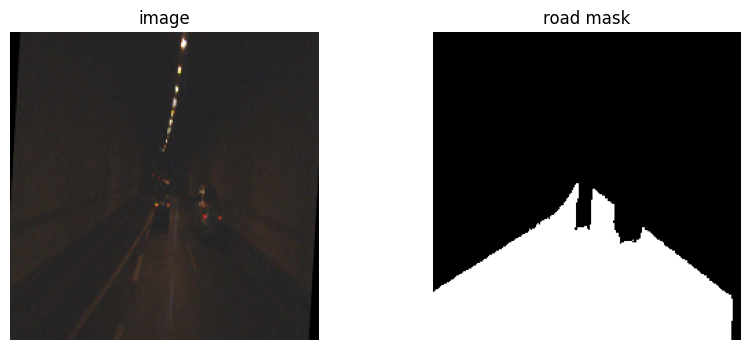

In [7]:
class KittiGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, label_paths, indices, batch_size, augment, shuffle=True):
        self.img_paths = img_paths
        self.label_paths = label_paths
        self.indices = list(indices)
        self.batch_size = batch_size
        self.aug = augment
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return len(self.indices) // self.batch_size

    def on_epoch_end(self):
        if self.shuffle:
            random.shuffle(self.indices)

    def __getitem__(self, i):
        batch = self.indices[i*self.batch_size:(i+1)*self.batch_size]
        X, Y = [], []
        for j in batch:
            img = cv2.imread(self.img_paths[j])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            lbl = cv2.imread(self.label_paths[j], cv2.IMREAD_GRAYSCALE)
            mask = (lbl == ROAD_ID).astype("uint8")

            a = self.aug(image=img, mask=mask)
            img_a, mask_a = a["image"], a["mask"]

            X.append(img_a.astype("float32") / 255.0)
            Y.append(mask_a.astype("float32")[..., np.newaxis])
        return np.array(X), np.array(Y)

train_gen = KittiGenerator(img_paths, label_paths, train_idx, BATCH_SIZE, get_augmentation(True))
val_gen   = KittiGenerator(img_paths, label_paths, val_idx,   BATCH_SIZE, get_augmentation(False), shuffle=False)

xb, yb = train_gen[0]
print("배치 이미지:", xb.shape, "| 배치 마스크:", yb.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(xb[0]); ax[0].set_title("image"); ax[0].axis("off")
ax[1].imshow(yb[0, ..., 0], cmap="gray"); ax[1].set_title("road mask"); ax[1].axis("off")
plt.show()


---
## Step 2. U-Net++ 모델의 구현

공통 `conv_block`(Conv–BN–ReLU ×2)을 쓰고, 업샘플은 `Conv2DTranspose`
(= 앞서 본 **Transpose2D_block**의 핵심)로 한다.
두 모델을 **같은 필터/블록**으로 만들어 순수하게 *skip 연결 구조 차이*만 비교한다.


In [8]:
def conv_block(x, filters, name):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=name+"_c1")(x)
    x = layers.BatchNormalization(name=name+"_bn1")(x)
    x = layers.Activation("relu", name=name+"_re1")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, name=name+"_c2")(x)
    x = layers.BatchNormalization(name=name+"_bn2")(x)
    x = layers.Activation("relu", name=name+"_re2")(x)
    return x

def up(x, filters, name):
    # Transpose2D_block의 핵심: 학습 가능한 2배 업샘플
    return layers.Conv2DTranspose(filters, 2, strides=2, padding="same", name=name+"_up")(x)

FILT = [32, 64, 128, 256, 512]


### 2-1. U-Net (기준 모델)

In [9]:
def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inp = layers.Input(input_shape)
    f = FILT
    c1 = conv_block(inp, f[0], "e1"); p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1,  f[1], "e2"); p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2,  f[2], "e3"); p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3,  f[3], "e4"); p4 = layers.MaxPool2D()(c4)
    bn = conv_block(p4, f[4], "bn")
    d4 = conv_block(layers.concatenate([up(bn, f[3], "d4"), c4]), f[3], "dd4")
    d3 = conv_block(layers.concatenate([up(d4, f[2], "d3"), c3]), f[2], "dd3")
    d2 = conv_block(layers.concatenate([up(d3, f[1], "d2"), c2]), f[1], "dd2")
    d1 = conv_block(layers.concatenate([up(d2, f[0], "d1"), c1]), f[0], "dd1")
    out = layers.Conv2D(1, 1, activation="sigmoid", name="out")(d1)
    return Model(inp, out, name="U_Net")

build_unet().summary()


Model: "U_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e1_c1 (Conv2D)      │ (None, 224, 224,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e1_bn1              │ (None, 224, 224,  │        128 │ e1_c1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e1_re1 (Activation) │ (None, 224, 224,  │          0 │ e1_bn1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e1_c2 (Conv2D)      │ (None, 224, 224,  │      9,216 │ e1_re1[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e1_bn2              │ (None, 224, 224,  │        128 │ e1_c2[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e1_re2 (Activation) │ (None, 224, 224,  │          0 │ e1_bn2[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ e1_re2[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e2_c1 (Conv2D)      │ (None, 112, 112,  │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e2_bn1              │ (None, 112, 112,  │        256 │ e2_c1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e2_re1 (Activation) │ (None, 112, 112,  │          0 │ e2_bn1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e2_c2 (Conv2D)      │ (None, 112, 112,  │     36,864 │ e2_re1[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e2_bn2              │ (None, 112, 112,  │        256 │ e2_c2[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e2_re2 (Activation) │ (None, 112, 112,  │          0 │ e2_bn2[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ e2_re2[0][0]      │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e3_c1 (Conv2D)      │ (None, 56, 56,    │     73,728 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ e3_bn1              │ (None, 56, 56,    │        512 │ e3_c1[0][0]     

 Total params: 7,768,929 (29.64 MB)

 Trainable params: 7,763,041 (29.61 MB)

 Non-trainable params: 5,888 (23.00 KB)

### 2-2. U-Net++ (중첩 dense skip)

노드 `X[i][j]` — `i`는 깊이(다운샘플 단계), `j`는 열(dense 경로 위치).
`X[i][j]`는 **같은 행의 이전 노드 전부**(`X[i][0..j-1]`)와
**아래 행에서 업샘플한 노드**(`up(X[i+1][j-1])`)를 concat해서 만든다.
`deep_supervision=True`면 X[0][1..4]에서 각각 출력을 뽑아 평균한다.


In [10]:
def build_unetpp(input_shape=(IMG_SIZE, IMG_SIZE, 3), deep_supervision=False):
    inp = layers.Input(input_shape)
    f = FILT
    cat = layers.concatenate

    x00 = conv_block(inp, f[0], "x00"); p0 = layers.MaxPool2D()(x00)
    x10 = conv_block(p0,  f[1], "x10"); p1 = layers.MaxPool2D()(x10)
    x20 = conv_block(p1,  f[2], "x20"); p2 = layers.MaxPool2D()(x20)
    x30 = conv_block(p2,  f[3], "x30"); p3 = layers.MaxPool2D()(x30)
    x40 = conv_block(p3,  f[4], "x40")

    x01 = conv_block(cat([x00, up(x10, f[0], "u01")]), f[0], "x01")
    x11 = conv_block(cat([x10, up(x20, f[1], "u11")]), f[1], "x11")
    x21 = conv_block(cat([x20, up(x30, f[2], "u21")]), f[2], "x21")
    x31 = conv_block(cat([x30, up(x40, f[3], "u31")]), f[3], "x31")

    x02 = conv_block(cat([x00, x01, up(x11, f[0], "u02")]), f[0], "x02")
    x12 = conv_block(cat([x10, x11, up(x21, f[1], "u12")]), f[1], "x12")
    x22 = conv_block(cat([x20, x21, up(x31, f[2], "u22")]), f[2], "x22")

    x03 = conv_block(cat([x00, x01, x02, up(x12, f[0], "u03")]), f[0], "x03")
    x13 = conv_block(cat([x10, x11, x12, up(x22, f[1], "u13")]), f[1], "x13")

    x04 = conv_block(cat([x00, x01, x02, x03, up(x13, f[0], "u04")]), f[0], "x04")

    if deep_supervision:
        o1 = layers.Conv2D(1, 1, activation="sigmoid", name="o1")(x01)
        o2 = layers.Conv2D(1, 1, activation="sigmoid", name="o2")(x02)
        o3 = layers.Conv2D(1, 1, activation="sigmoid", name="o3")(x03)
        o4 = layers.Conv2D(1, 1, activation="sigmoid", name="o4")(x04)
        out = layers.Average(name="out")([o1, o2, o3, o4])
    else:
        out = layers.Conv2D(1, 1, activation="sigmoid", name="out")(x04)
    return Model(inp, out, name="U_Net_pp")

build_unetpp().summary()


Model: "U_Net_pp"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x00_c1 (Conv2D)     │ (None, 224, 224,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x00_bn1             │ (None, 224, 224,  │        128 │ x00_c1[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x00_re1             │ (None, 224, 224,  │          0 │ x00_bn1[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x00_c2 (Conv2D)     │ (None, 224, 224,  │      9,216 │ x00_re1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x00_bn2             │ (None, 224, 224,  │        128 │ x00_c2[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x00_re2             │ (None, 224, 224,  │          0 │ x00_bn2[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 112, 112,  │          0 │ x00_re2[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x10_c1 (Conv2D)     │ (None, 112, 112,  │     18,432 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x10_bn1             │ (None, 112, 112,  │        256 │ x10_c1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x10_re1             │ (None, 112, 112,  │          0 │ x10_bn1[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x10_c2 (Conv2D)     │ (None, 112, 112,  │     36,864 │ x10_re1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x10_bn2             │ (None, 112, 112,  │        256 │ x10_c2[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x10_re2             │ (None, 112, 112,  │          0 │ x10_bn2[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 56, 56,    │          0 │ x10_re2[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x20_c1 (Conv2D)     │ (None, 56, 56,    │     73,728 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ x20_bn1             │ (None, 56, 56,    │        512 │ x20_c1[0][0]    

 Total params: 9,053,121 (34.53 MB)

 Trainable params: 9,045,825 (34.51 MB)

 Non-trainable params: 7,296 (28.50 KB)

---
## Step 3. 결과 분석 (U-Net vs U-Net++)

같은 손실(BCE)·같은 지표(IoU)·같은 데이터로 학습하고 정량/정성 비교한다.


In [11]:
EPOCHS = 20   # 시간이 부족하면 10으로. GPU 권장.

def make_iou_metric():
    return tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5, name="road_iou")

def compile_and_train(model):
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=[make_iou_metric()])
    es = tf.keras.callbacks.EarlyStopping(monitor="val_road_iou", mode="max",
                                          patience=6, restore_best_weights=True)
    hist = model.fit(train_gen, validation_data=val_gen,
                     epochs=EPOCHS, callbacks=[es], verbose=1)
    return hist


In [12]:
print("===== U-Net 학습 =====")
unet = build_unet()
hist_unet = compile_and_train(unet)

print("\n===== U-Net++ 학습 =====")
unetpp = build_unetpp()
hist_unetpp = compile_and_train(unetpp)


===== U-Net 학습 =====
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


40/40 ━━━━━━━━━━━━━━━━━━━━ 44s 229ms/step - loss: 0.3593 - road_iou: 0.5489 - val_loss: 64.9281 - val_road_iou: 0.2248
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.2302 - road_iou: 0.6916 - val_loss: 11.0350 - val_road_iou: 0.2344
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.1968 - road_iou: 0.7139 - val_loss: 0.9888 - val_road_iou: 0.5101
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - loss: 0.1832 - road_iou: 0.7300 - val_loss: 3.3386 - val_road_iou: 0.2937
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.1673 - road_iou: 0.7442 - val_loss: 3.1400 - val_road_iou: 0.3078
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - loss: 0.1682 - road_iou: 0.7407 - val_loss: 0.4788 - val_road_iou: 0.5825
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.1555 - road_iou: 0.7499 - val_loss: 0.4511 - val_road_iou: 0.5633
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - loss: 0.1537 - road_iou: 0.7561 - val_loss: 0.4740 - val_r

### 3-1. 정량 비교 — 검증셋 mean IoU

U-Net   road IoU : 0.8068
U-Net++ road IoU : 0.8255
차이(++ - Net)   : +0.0187


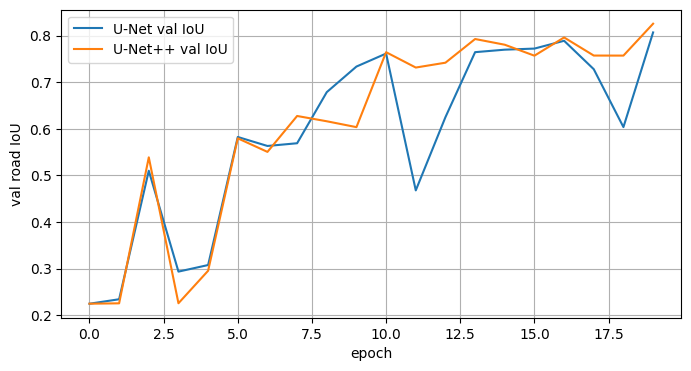

In [13]:
def eval_mean_iou(model, gen):
    m = tf.keras.metrics.BinaryIoU(target_class_ids=[1], threshold=0.5)
    for i in range(len(gen)):
        x, y = gen[i]
        m.update_state(y, model.predict(x, verbose=0))
    return float(m.result())

iou_unet   = eval_mean_iou(unet,   val_gen)
iou_unetpp = eval_mean_iou(unetpp, val_gen)
print(f"U-Net   road IoU : {iou_unet:.4f}")
print(f"U-Net++ road IoU : {iou_unetpp:.4f}")
print(f"차이(++ - Net)   : {iou_unetpp - iou_unet:+.4f}")

plt.figure(figsize=(8,4))
plt.plot(hist_unet.history["val_road_iou"],   label="U-Net val IoU")
plt.plot(hist_unetpp.history["val_road_iou"], label="U-Net++ val IoU")
plt.xlabel("epoch"); plt.ylabel("val road IoU"); plt.legend(); plt.grid(True); plt.show()


### 3-2. 정성 비교 — 예측 마스크 시각화

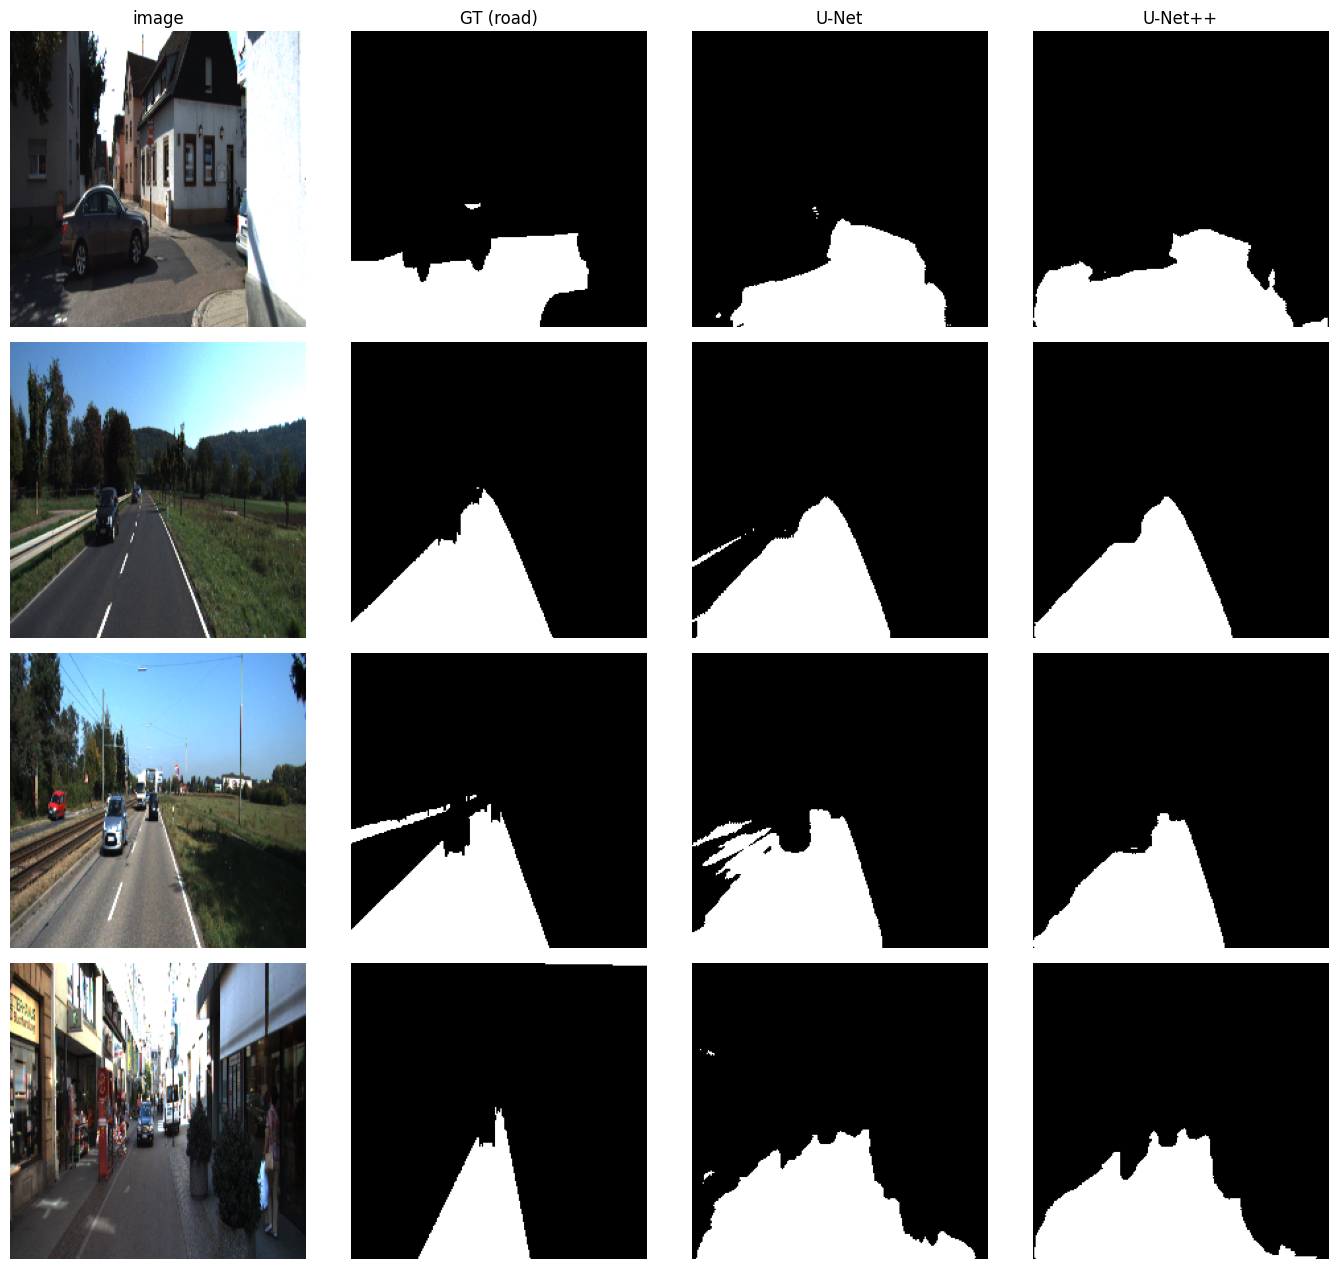

In [14]:
def show_predictions(n=4):
    x, y = val_gen[0]
    p1 = unet.predict(x, verbose=0)
    p2 = unetpp.predict(x, verbose=0)
    n = min(n, len(x))
    fig, ax = plt.subplots(n, 4, figsize=(14, 3.2*n))
    if n == 1: ax = ax[np.newaxis, :]
    cols = ["image", "GT (road)", "U-Net", "U-Net++"]
    for r in range(n):
        ax[r,0].imshow(x[r])
        ax[r,1].imshow(y[r,...,0], cmap="gray")
        ax[r,2].imshow((p1[r,...,0] > 0.5), cmap="gray")
        ax[r,3].imshow((p2[r,...,0] > 0.5), cmap="gray")
        for c in range(4):
            ax[r,c].axis("off")
            if r == 0: ax[r,c].set_title(cols[c])
    plt.tight_layout(); plt.show()

show_predictions(4)


---
## 정리 / 회고

- **Step 1**: KITTI 200장을 8:2로 나눠 albumentations 증강 + 이진 도로 마스크 제너레이터 구성.
- **Step 2**: 같은 conv 블록 위에 U-Net(단일 skip)과 U-Net++(중첩 dense skip, Conv2DTranspose 업샘플)를 구현.
- **Step 3**: BCE 손실·road IoU로 정량 비교 + 예측 마스크 정성 비교.

**추가 실험 아이디어**
- `build_unetpp(deep_supervision=True)`로 deep supervision 효과 확인
- 인코더를 VGG16/ResNet 백본(전이학습)으로 교체
- 손실을 BCE+Dice로 바꿔 경계 품질 개선

> 데이터가 적어 IoU 절대값은 낮을 수 있다. 핵심은 **동일 조건에서의 상대 비교**다.
